# DynaSD Quickstart

End-to-end seizure detection on a bundled synthetic example.

This notebook walks through the four steps that make up every DynaSD pipeline:

1. **Load data** — get a seizure recording.
2. **Fit** — calibrate a detector on the baseline portion.
3. **Forward** — score every window of the full recording.
4. **Annotate** — call `get_onset_and_spread` to extract per-channel onset times.

We use the closed-form `HFER` detector here for speed; every detector class in
`DynaSD.__all__` (e.g. `ABSSLP`, `IMPRINT`, `NDD`, `GIN`, `LiNDDA`) follows the
same `fit` → `forward` → `get_onset_and_spread` interface.


## 1. Load the bundled example

`DynaSD.load_example_seizure()` returns a synthetic 60 s recording (8 channels,
fs=256 Hz) with a polyspike seizure planted at t=30 s on the first 4 channels.
The remaining 4 channels stay baseline throughout.

In [1]:
# If DynaSD isn't installed, fall back to importing from the repo root.
import sys, pathlib
_repo = pathlib.Path.cwd().parent
if (_repo / 'DynaSD').is_dir() and str(_repo) not in sys.path:
    sys.path.insert(0, str(_repo))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dynasd import HFER, load_example_seizure

example = load_example_seizure()
X = example.signal              # pd.DataFrame, shape (n_samples, n_channels)
fs = example.fs                 # 256 Hz
sz_start = example.seizure_start_sec   # 30.0
sz_end = example.seizure_end_sec       # 60.0
focal = example.focal_channels         # ['Ch01', 'Ch02', 'Ch03', 'Ch04']

print(f"signal: {X.shape}  fs={fs}  duration={len(X)/fs:.1f}s")
print(f"planted seizure: {sz_start}-{sz_end}s on {focal}")

signal: (15360, 8)  fs=256  duration=60.0s
planted seizure: 30.0-60.0s on ['Ch01', 'Ch02', 'Ch03', 'Ch04']


Quick look at the raw signal — focal channels in red, baseline in black.

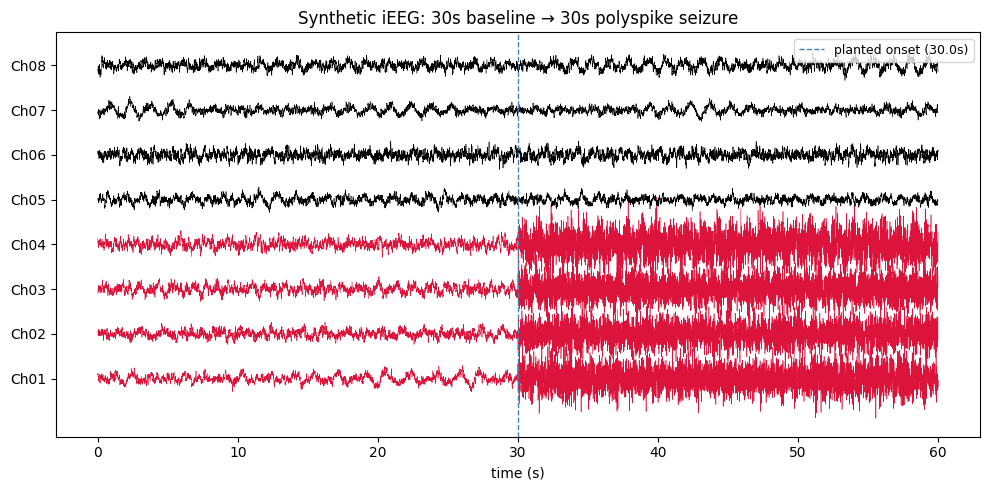

In [2]:
t = np.arange(len(X)) / fs
fig, ax = plt.subplots(figsize=(10, 5))
spacing = X.std().median() * 8
for i, ch in enumerate(X.columns):
    color = "crimson" if ch in focal else "black"
    ax.plot(t, X[ch].values - X[ch].mean() + i * spacing, color=color, lw=0.4)
ax.axvline(sz_start, color="steelblue", ls="--", lw=1, label=f"planted onset ({sz_start}s)")
ax.set_yticks([i * spacing for i in range(len(X.columns))])
ax.set_yticklabels(X.columns)
ax.set_xlabel("time (s)")
ax.set_title("Synthetic iEEG: 30s baseline → 30s polyspike seizure")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

## 2. Fit the detector on the baseline

Detectors learn per-channel reference statistics from a stretch of pre-ictal
data. Pass only the baseline portion to `fit`.

In [3]:
baseline = X.iloc[: int(sz_start * fs)]   # first 30 seconds

model = HFER(fs=fs, w_size=1.0, w_stride=0.5)
model.fit(baseline)
print(f"model fitted: {model.is_fitted}")

model fitted: True


## 3. Forward-pass the full recording

`model.forward(X)` returns a `pd.DataFrame` of per-window detector scores. The
row index is the window-start time in seconds (named ``t_sec``); columns match
the input channel names.

In [4]:
sz_prob = model(X)
print(f"sz_prob: {sz_prob.shape}  index name='{sz_prob.index.name}'")
sz_prob.head()

sz_prob: (119, 8)  index name='t_sec'


,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07,Ch08
t_sec,,,,,,,,
0.0,0.681297,0.309717,0.496864,0.303883,0.744889,0.524364,1.196222,0.257725
0.5,0.437108,0.865664,1.022851,1.484190,1.524428,0.833351,0.326716,0.247494
1.0,0.720892,0.648854,4.532057,0.359944,1.493482,0.327490,0.228026,0.747713
1.5,3.139069,0.667332,0.338741,0.319491,0.657080,0.374541,0.532331,1.291026
2.0,0.604084,1.068440,0.630426,0.490594,0.889788,1.603790,0.387690,0.444119


## 4. Annotate onset and spread

`get_onset_and_spread` smooths the per-window scores, thresholds them, and
applies a sustained-activity criterion to extract per-channel seizure onset
times.

**Key parameters** (all in seconds):
- `threshold` — score above which a window counts as seizing.
- `filter_w` — smoothing window length (uniform filter on the score).
- `rwin_size` — lookahead span for the spread criterion.
- `rwin_req` — required active duration within `rwin_size` to flag onset.

The defaults (`filter_w=10s, rwin_size=5s, rwin_req=4s`) work well; pick
`threshold` based on the baseline distribution. For HFER on this fixture,
`threshold=8.0` separates baseline from seizure cleanly.

In [5]:
onsets, sz_spread = model.get_onset_and_spread(
    sz_prob,
    threshold=8.0,
    filter_w=10.0,
    rwin_size=5.0,
    rwin_req=4.0,
    ret_smooth_mat=True,
)

# ``onsets`` is a single-row DataFrame: per-channel onset time in seconds
# (NaN for channels that never reach sustained activity).
onsets.T.rename(columns={0: "detected_onset_sec"})

,detected_onset_sec
Ch01,27.5
Ch03,27.5
Ch02,28.5
Ch04,31.0
Ch05,NaN
Ch06,NaN
Ch07,NaN
Ch08,NaN


## 5. Visualize the detector output

`sz_prob` is the per-window detector score per channel. Plotting it as a
heatmap (channels sorted by detected onset time, with non-detecting channels
at the bottom) shows which channels light up and when, before any
threshold-based annotation.

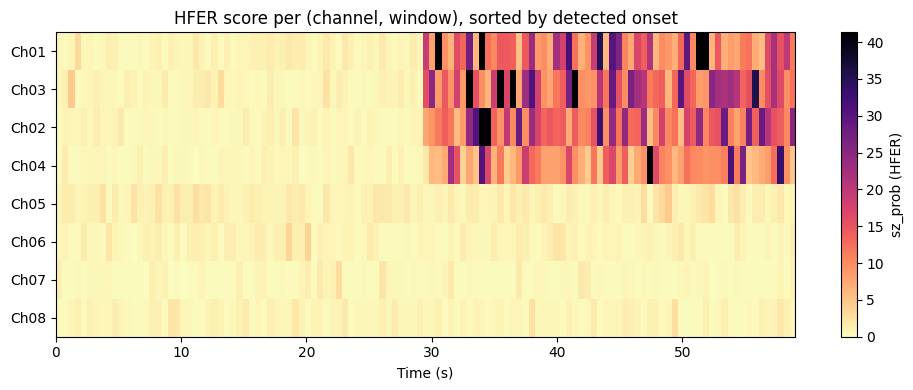

In [6]:
# Sort channels by detected onset time; NaN onsets sink to the bottom.
detected = onsets.iloc[0]
order = sorted(
    X.columns,
    key=lambda c: (np.inf if pd.isna(detected[c]) else detected[c], c),
)
sorted_idx = [list(X.columns).index(c) for c in order]

fig, ax = plt.subplots(figsize=(10, 4))
heatmap = sz_prob[order].T.values  # (n_channels, n_windows)
extent = [sz_prob.index[0], sz_prob.index[-1], len(order), 0]  # y inverted: row 0 at top
im = ax.imshow(heatmap, aspect="auto", cmap="magma_r", extent=extent,
               vmin=0, vmax=np.percentile(heatmap, 99))
ax.set_yticks(np.arange(len(order)) + 0.5)
ax.set_yticklabels(order)
ax.set_xlabel("Time (s)")
ax.set_title("HFER score per (channel, window), sorted by detected onset")
fig.colorbar(im, ax=ax, label="sz_prob (HFER)")
fig.tight_layout()
plt.show()

## 6. Annotated seizure boundary

Plot the raw signal stacked per channel (sorted by detected onset), and
overlay the recruitment curve — the orange line traces each channel's
detected onset time as new channels join the seizure. Channels that never
reach sustained activity sit below the curve's plateau.

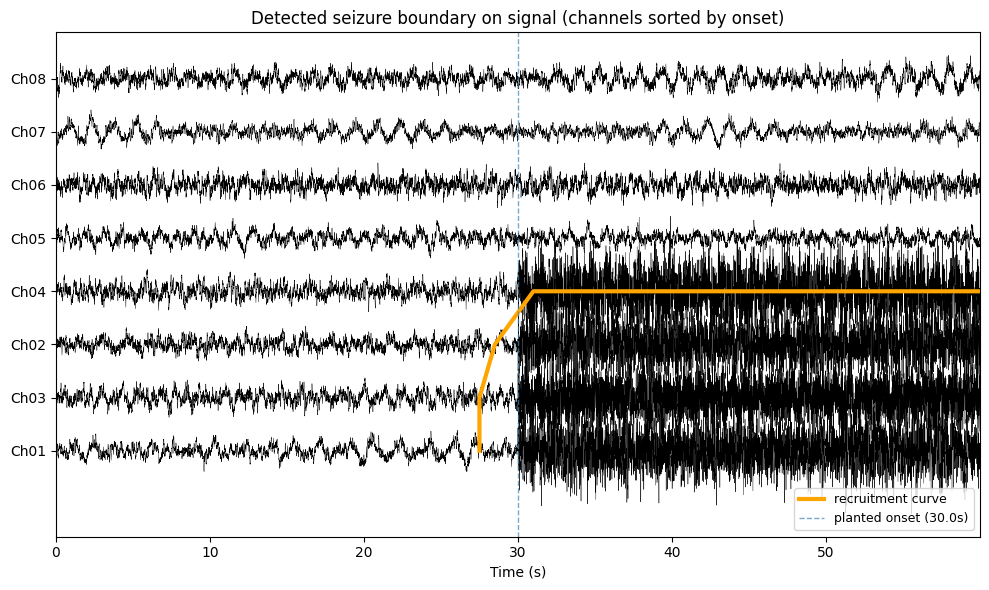

In [7]:
t_full = np.arange(len(X)) / fs

fig, ax = plt.subplots(figsize=(10, 6))
spacing = X.std().median() * 6
for i, ch in enumerate(order):
    sig = X[ch].values - X[ch].mean()
    ax.plot(t_full, sig + i * spacing, color="black", lw=0.3)

# Recruitment curve: (detection_time, channel_rank) for detected channels.
# Append a flat extension to the right edge after the last recruitment so the
# curve covers the full x-range like a typical spread plot.
rec = [(detected[ch], i) for i, ch in enumerate(order) if not pd.isna(detected[ch])]
if rec:
    xs, ys = zip(*rec)
    xs = list(xs) + [t_full[-1]]
    ys = list(ys) + [ys[-1]]
    ax.plot(xs, [y * spacing for y in ys], color="orange", lw=3, label="recruitment curve")

ax.axvline(sz_start, color="steelblue", ls="--", lw=1, alpha=0.7,
           label=f"planted onset ({sz_start}s)")
ax.set_yticks([i * spacing for i in range(len(order))])
ax.set_yticklabels(order)
ax.set_xlabel("Time (s)")
ax.set_title("Detected seizure boundary on signal (channels sorted by onset)")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(t_full[0], t_full[-1])
fig.tight_layout()
plt.show()

## What's next

- **Try a different detector**: swap `HFER(...)` for `ABSSLP`, `IMPRINT`, or any
  of the NDD-family forecasters (`NDD`, `GIN`, `LiNDDA`). The fit/forward/annotate
  interface is identical.
- **Tune `threshold`** to your own data — the baseline-mean of the smoothed output
  is a reasonable starting point.
- **Bring your own data**: any `(n_samples, n_channels)` `pd.DataFrame` with a
  fixed sampling rate works; `fit` on a clean baseline window, then `forward` on
  the full recording.
- **See the spec** at `docs/spec_windowing_smoothing.md` for the exact
  windowing/smoothing/spread math.
